In [1]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузка датасета "Рукописные цифры" (1797 объектов изначально) (10 классов)
np.random.seed(42)

X, y = load_digits(return_X_y=True)

X = X + np.random.normal(0, 0.5, X.shape)

print("Размерность данных:", X.shape, np.unique(y))

Размерность данных: (1797, 64) [0 1 2 3 4 5 6 7 8 9]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y # Фиксируем разбиение выборок: 80% обучающей и 20% тестовой
)

n_estimators_range = list(range(50, 110, 10)) # Варьируем количество участников ансамбля

metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

In [4]:
# Обучаем модели
max_samples_values = [0.5, 1.0]
max_features_values = ['sqrt', 'log2']
all_results = {}

for max_s in max_samples_values:
    for max_f in max_features_values:
        param_key = f"samples={max_s}, features={max_f}"
        all_results[param_key] = {
            'n_estimators': [],
            'accuracy': [],
            'precision': [],
            'recall': [],
            'f1': []
        }

        for n in n_estimators_range:
            rf_model = RandomForestClassifier(
                n_estimators=n,
                criterion="gini",
                max_samples=max_s,
                max_features=max_f,
                bootstrap=True,
                random_state=42,
            )

            rf_model.fit(X_train, y_train)
            y_pred = rf_model.predict(X_test)

            all_results[param_key]['n_estimators'].append(n)
            all_results[param_key]['accuracy'].append(accuracy_score(y_test, y_pred))
            all_results[param_key]['precision'].append(precision_score(y_test, y_pred, average='macro'))
            all_results[param_key]['recall'].append(recall_score(y_test, y_pred, average='macro'))
            all_results[param_key]['f1'].append(f1_score(y_test, y_pred, average='macro'))

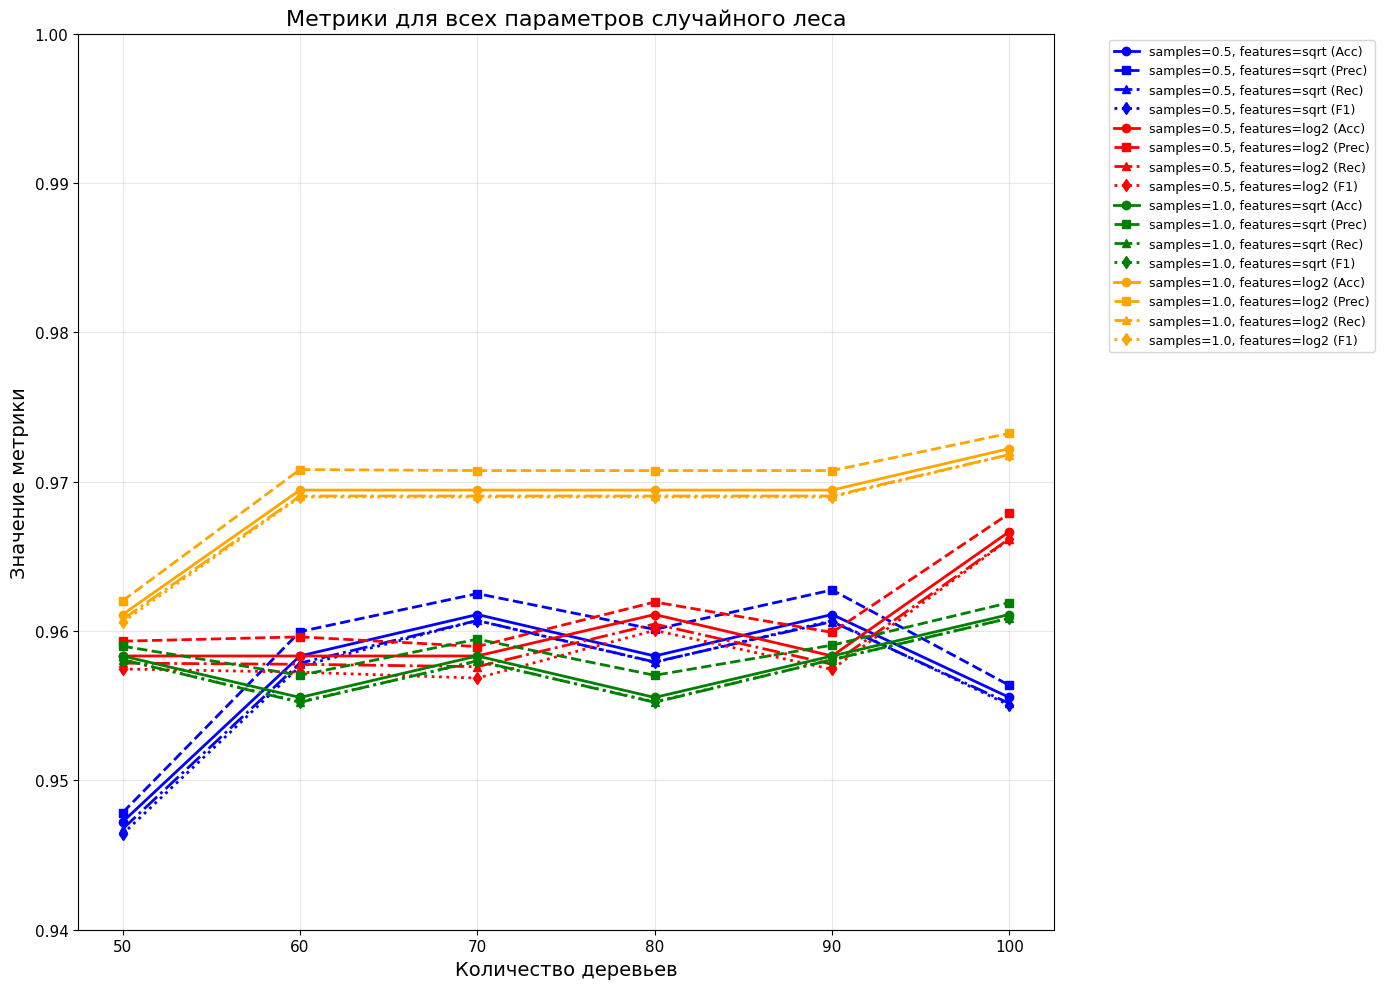

In [5]:
plt.figure(figsize=(14, 10))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd']
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for idx, (param_key, metrics) in enumerate(all_results.items()):
    color = colors[idx % len(colors)]

    # Accuracy
    plt.plot(metrics['n_estimators'],
            metrics['accuracy'],
            linestyle='-',
            marker='o',
            color=color,
            linewidth=2,
            label=f'{param_key} (Acc)')

    # Precision
    plt.plot(metrics['n_estimators'],
            metrics['precision'],
            linestyle='--',
            marker='s',
            color=color,
            linewidth=2,
            label=f'{param_key} (Prec)')

    # Recall
    plt.plot(metrics['n_estimators'],
            metrics['recall'],
            linestyle='-.',
            marker='^',
            color=color,
            linewidth=2,
            label=f'{param_key} (Rec)')

    # F1
    plt.plot(metrics['n_estimators'],
            metrics['f1'],
            linestyle=':',
            marker='d',
            color=color,
            linewidth=2,
            label=f'{param_key} (F1)')

plt.xlabel("Количество деревьев", fontsize=14)
plt.ylabel("Значение метрики", fontsize=14)
plt.title("Метрики для всех параметров случайного леса", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)

plt.xticks(n_estimators_range, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.94, 1)

plt.tight_layout()
plt.show()

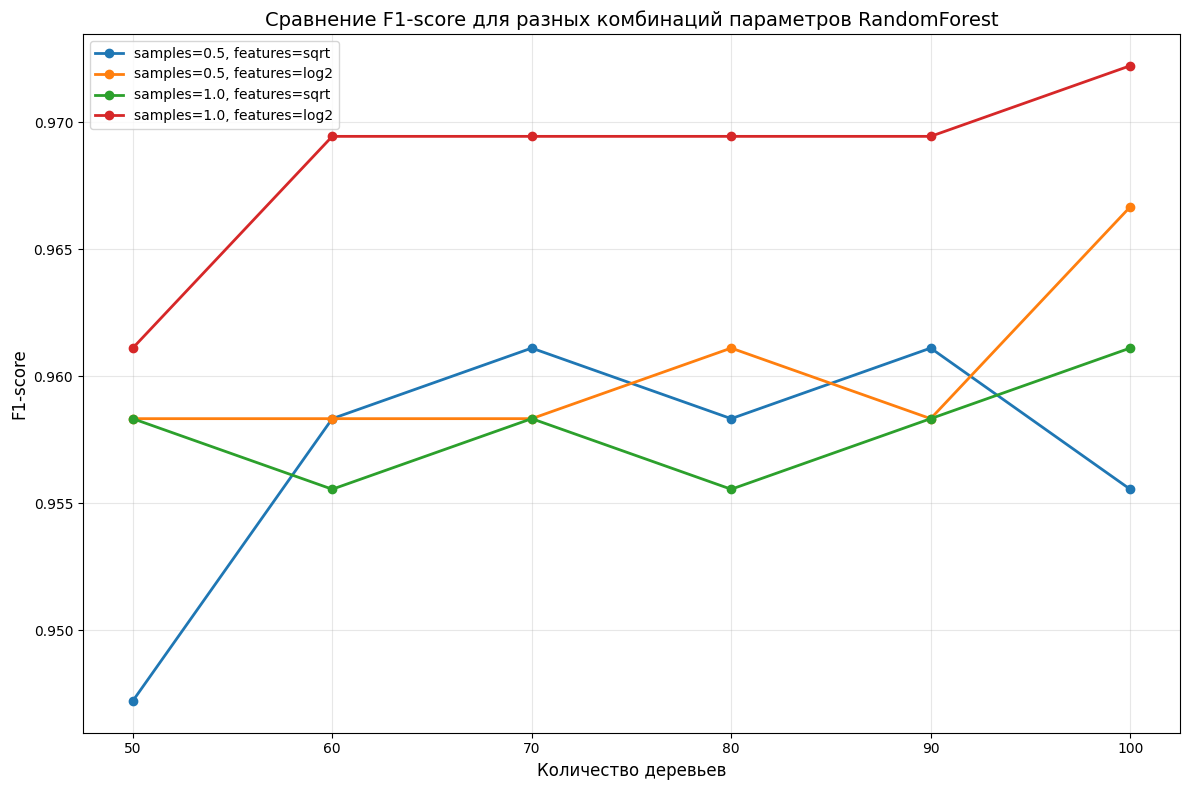

In [6]:
# График для сравнения F1-score
plt.figure(figsize=(12, 8))

for param_key, metrics in all_results.items():
    plt.plot(metrics['n_estimators'],
            metrics['accuracy'],
            marker='o',
            linewidth=2,
            label=param_key)

plt.xlabel("Количество деревьев", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.title("Сравнение F1-score для разных комбинаций параметров RandomForest", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(n_estimators_range)
plt.tight_layout()
plt.show()

In [7]:
# Варьируем размер обучающей выборки
train_ratios = list(range(50, 100, 5))

metrics_tree = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

metrics_bayes = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

metrics_bagging = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for tr in train_ratios:

    ratio = tr / 100

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    # Дерево решений (Gini)
    tree_model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    )

    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    metrics_tree["accuracy"].append(accuracy_score(y_test, y_pred_tree))
    metrics_tree["precision"].append(precision_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["recall"].append(recall_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["f1"].append(f1_score(y_test, y_pred_tree, average="macro"))


    # Байесовская классификация
    bayes_model = GaussianNB()
    bayes_model.fit(X_train, y_train)
    y_pred_bayes = bayes_model.predict(X_test)

    metrics_bayes["accuracy"].append(accuracy_score(y_test, y_pred_bayes))
    metrics_bayes["precision"].append(precision_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["recall"].append(recall_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["f1"].append(f1_score(y_test, y_pred_bayes, average="macro"))


# Обучаем модели + беггинг
for n in n_estimators_range:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        criterion="gini",
        max_samples=1.0,
        max_features='log2',
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, average="macro"))
    metrics["recall"].append(recall_score(y_test, y_pred, average="macro"))
    metrics["f1"].append(f1_score(y_test, y_pred, average="macro"))

    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        max_samples=1.0,
        max_features=0.5,
        n_estimators=n,
        random_state=42
    )

    bagging_model.fit(X_train, y_train)
    y_pred = bagging_model.predict(X_test)

    metrics_bagging['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics_bagging['precision'].append(precision_score(y_test, y_pred, average='macro'))
    metrics_bagging['recall'].append(recall_score(y_test, y_pred, average='macro'))
    metrics_bagging['f1'].append(f1_score(y_test, y_pred, average='macro'))

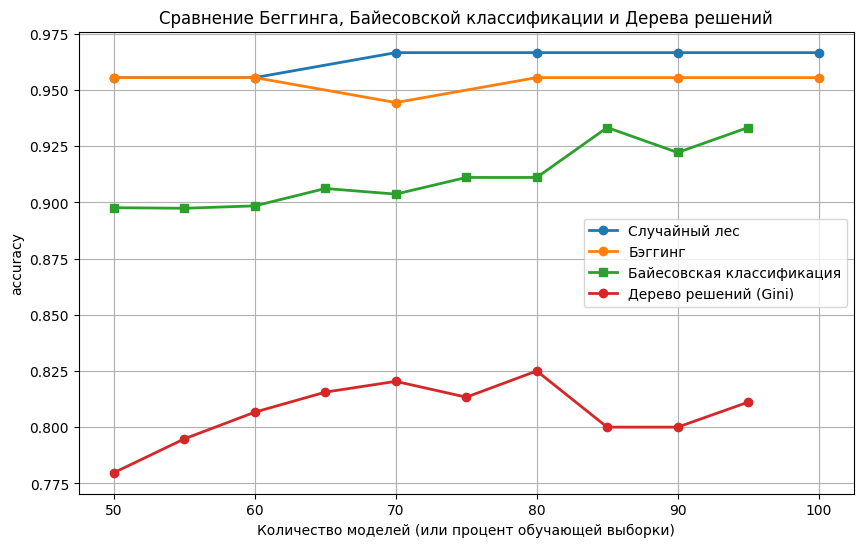

In [8]:
# Диаграмма сравнения различных моделей классификации на одной метрике
selected_metric = "accuracy"

rf_values = metrics[selected_metric]
bagging_values = metrics_bagging[selected_metric]
bayes_values = metrics_bayes[selected_metric]
tree_values = metrics_tree[selected_metric]

plt.figure(figsize=(10, 6))

plt.plot(n_estimators_range, rf_values, marker='o', linewidth=2, label="Случайный лес")
plt.plot(n_estimators_range, bagging_values, marker='o', linewidth=2, label='Бэггинг')
plt.plot(train_ratios, bayes_values, marker='s', linewidth=2, label="Байесовская классификация")
plt.plot(train_ratios, tree_values, marker='o', linewidth=2, label="Дерево решений (Gini)")

plt.xlabel("Количество моделей (или процент обучающей выборки)")
plt.ylabel(selected_metric)
plt.title("Сравнение Беггинга, Байесовской классификации и Дерева решений")
plt.legend()
plt.grid(True)
plt.show()
